<a href="https://colab.research.google.com/github/ChristianAgyapong/Medgemma/blob/main/TASK_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
# Reliable public URL for Telco Churn
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn distribution:\n", df['Churn'].value_counts(normalize=True))  # ~73% No, 27% Yes

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [ ]:
# Drop useless ID
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges (object → numeric, handle spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)  # new customers

# Convert target to 0/1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# One-hot encode all categorical columns
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("After encoding shape:", df.shape)

After encoding shape: (7043, 31)


/tmp/ipykernel_55/774175593.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)  # new customers


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale numerical columns only (RF doesn't require scaling, but good practice here)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 5634 | Test: 1409


In [ ]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

acc = rf_base.score(X_test, y_test)
print(f"Baseline Accuracy: {acc:.3f}")
print(f"Baseline ROC-AUC: {roc_auc_score(y_test, rf_base.predict_proba(X_test)[:, 1]):.3f}")
print("\nBaseline Classification Report:\n")
print(classification_report(y_test, y_pred_base))

Baseline Accuracy: 0.785
Baseline ROC-AUC: 0.825

Baseline Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']  # helps with imbalance
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1',            # focus on F1 for imbalanced
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_.round(3))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-score: 0.639


Test Accuracy:  0.767
Test ROC-AUC:    0.841

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



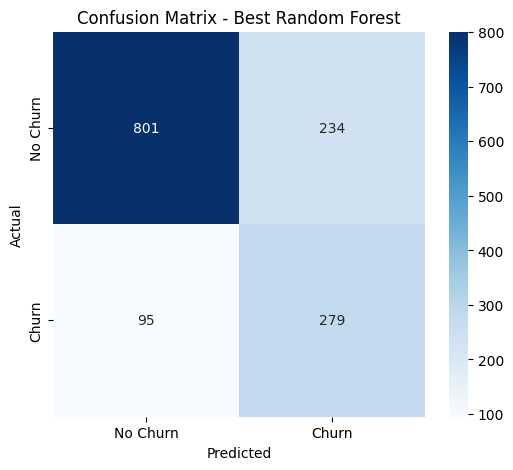

In [ ]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Fixed printing
acc = best_rf.score(X_test, y_test)
auc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy:  {acc:.3f}")
print(f"Test ROC-AUC:    {auc:.3f}")
print(f"\nClassification Report (Test):\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix (unchanged)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Best Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Top 10 Most Important Features:
                           Feature  Importance
0                           tenure    0.173244
1                     TotalCharges    0.142697
2                Contract_Two year    0.105645
3                   MonthlyCharges    0.103276
4      InternetService_Fiber optic    0.063983
5   PaymentMethod_Electronic check    0.050346
6                Contract_One year    0.042012
7               OnlineSecurity_Yes    0.037011
8                  TechSupport_Yes    0.024661
9  TechSupport_No internet service    0.020920


/tmp/ipykernel_55/85537401.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='viridis')


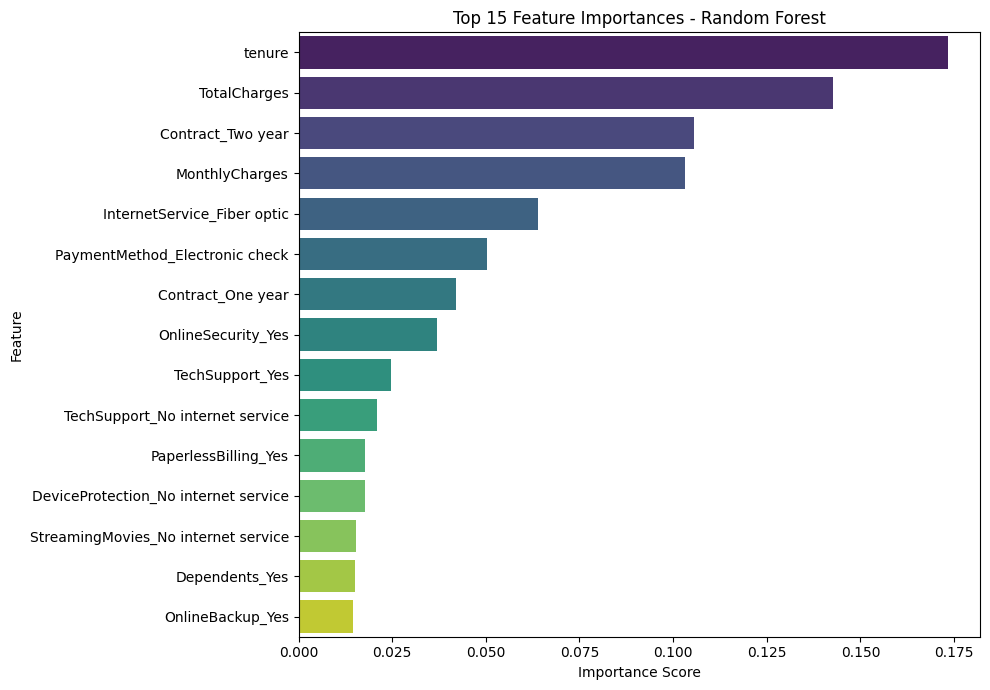

In [ ]:
# Feature importances from best model
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features:")
print(importances.head(10))

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()